**E-COMMERCE ANALYTICS**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv(r"D:\Analytics\All Projects\Global E-commerce Customer Analytics\Dataset\ecommerce_customer_analytics.csv")

**Phase-1: Data Cleaning and Validation**

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 25 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               1200 non-null   object 
 1   age                       1200 non-null   int64  
 2   gender                    1200 non-null   object 
 3   country                   1200 non-null   object 
 4   region                    1200 non-null   object 
 5   income_bracket            1200 non-null   object 
 6   signup_date               1200 non-null   object 
 7   last_purchase_date        1200 non-null   object 
 8   customer_lifetime_days    1200 non-null   int64  
 9   days_since_last_purchase  1200 non-null   int64  
 10  total_orders              1200 non-null   int64  
 11  total_spent_usd           1200 non-null   float64
 12  avg_order_value_usd       1200 non-null   float64
 13  preferred_category        1200 non-null   object 
 14  preferre

In [6]:
df.shape

(1200, 25)

In [7]:
df.describe()

,age,customer_lifetime_days,days_since_last_purchase,total_orders,total_spent_usd,avg_order_value_usd,discount_usage_rate,return_rate,avg_session_duration_min,avg_pages_per_session,satisfaction_score,churn
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.00000,1200.000000,1200.000000
mean,36.791667,640.200833,638.739167,54.095000,5300.141033,80.912325,0.257473,0.138565,8.040333,5.41300,3.378333,0.673333
std,11.766774,457.392649,485.209951,58.386415,9462.359979,48.874175,0.148585,0.107034,3.833465,2.37341,1.272090,0.469190
min,18.000000,1.000000,0.000000,1.000000,7.290000,4.990000,0.002000,0.001000,1.000000,1.00000,1.000000,0.000000
25%,28.000000,265.000000,249.000000,14.000000,795.420000,48.820000,0.142000,0.058000,5.200000,3.70000,3.000000,0.000000
50%,36.000000,550.000000,521.500000,35.000000,2195.495000,71.390000,0.229000,0.111000,7.900000,5.40000,4.000000,1.000000
75%,45.000000,935.250000,925.500000,72.250000,5827.155000,97.930000,0.350250,0.194000,10.700000,7.00000,4.000000,1.000000
max,75.000000,1995.000000,2152.000000,350.000000,107142.560000,363.730000,0.738000,0.641000,20.000000,12.90000,5.000000,1.000000


In [8]:
# Missing Values
df.isna().sum()

customer_id                 0
age                         0
gender                      0
country                     0
region                      0
income_bracket              0
signup_date                 0
last_purchase_date          0
customer_lifetime_days      0
days_since_last_purchase    0
total_orders                0
total_spent_usd             0
avg_order_value_usd         0
preferred_category          0
preferred_payment_method    0
device_type                 0
loyalty_tier                0
discount_usage_rate         0
return_rate                 0
newsletter_subscribed       0
referral_source             0
avg_session_duration_min    0
avg_pages_per_session       0
satisfaction_score          0
churn                       0
dtype: int64

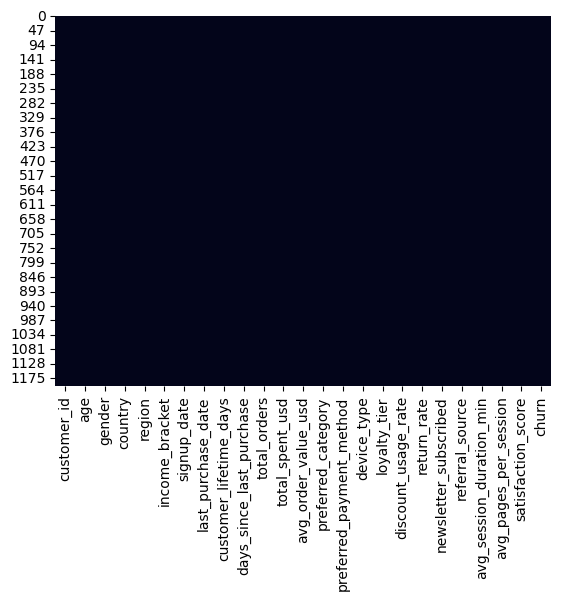

In [9]:
sns.heatmap(df.isnull(), cbar=False)
plt.show()

In [10]:
# Duplicate values
df.duplicated().sum()

np.int64(0)

**Phase 2: Exploratory Data Analysis (EDA)**

*1. AGE DISTRIBUTON*

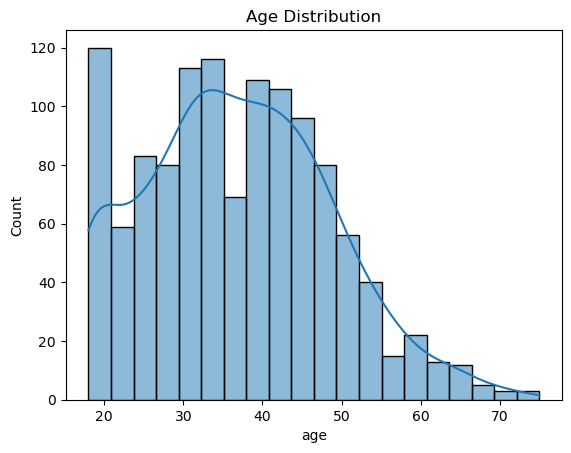

In [19]:
sns.histplot(
    df['age'],
    bins=20,
    kde=True
)
plt.title('Age Distribution')
plt.savefig(r"D:\Analytics\All Projects\Global E-commerce Customer Analytics\Charts")

*2. TOTAL SPENDING DISTRIBUTION*

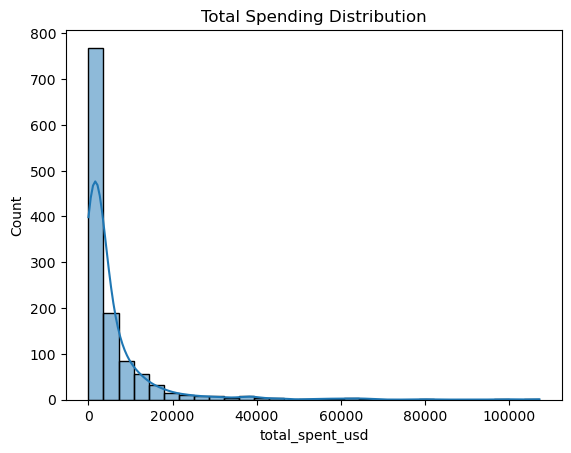

In [20]:
sns.histplot(
    df['total_spent_usd'],
    bins=30,
    kde=True
)
plt.title('Total Spending Distribution')
plt.savefig(r"D:\Analytics\All Projects\Global E-commerce Customer Analytics\Total_Spending_Dist")

*3. ORDER DISTRIBUTION*

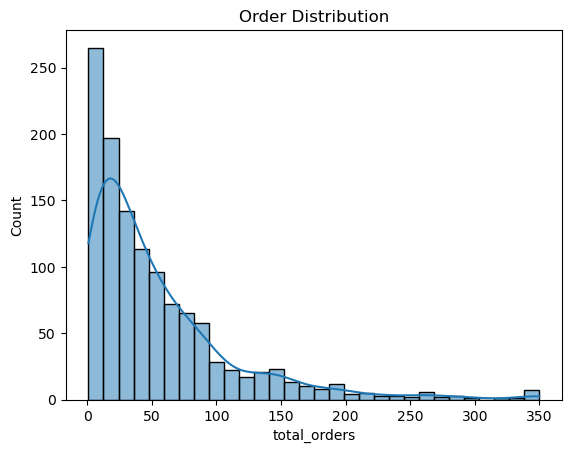

In [21]:
sns.histplot(
    df['total_orders'],
    bins=30,
    kde=True
)
plt.title('Order Distribution')
plt.savefig(r"D:\Analytics\All Projects\Global E-commerce Customer Analytics\Order Distribution")

*4. SESSION DURATION DISTRIBUTION*

<Axes: xlabel='avg_session_duration_min', ylabel='Count'>

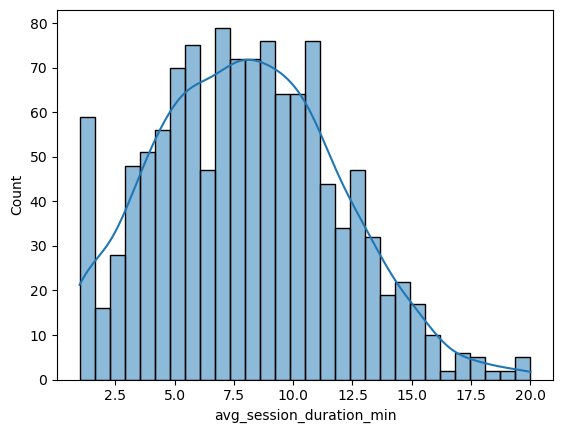

In [14]:
sns.histplot(
    df['avg_session_duration_min'],
    bins=30,
    kde=True
)

**Phase 3: Outlier Analysis**

*SPENDING OUTLIERS*

In [15]:
Q1 = df['total_spent_usd'].quantile(0.25)
Q3 = df['total_spent_usd'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

In [16]:
outliers = df[
    (df['total_spent_usd'] < lower)
    |
    (df['total_spent_usd'] > upper)
]

<Axes: xlabel='total_spent_usd'>

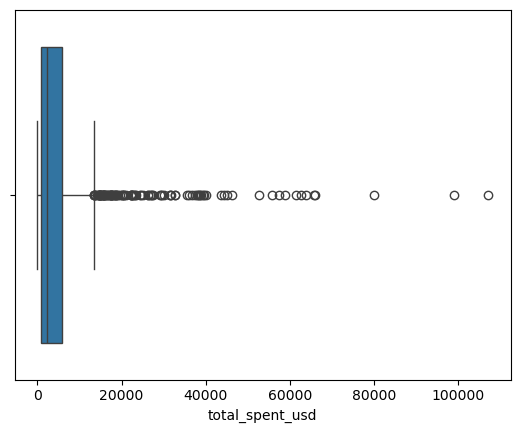

In [17]:
# VISUALIZE
sns.boxplot(x=df['total_spent_usd'])

*INVESTIGATE OUTLIERS*

In [18]:
outliers.sort_values(
    'total_spent_usd',
    ascending=False
)

,customer_id,age,gender,country,region,income_bracket,signup_date,last_purchase_date,customer_lifetime_days,days_since_last_purchase,...,device_type,loyalty_tier,discount_usage_rate,return_rate,newsletter_subscribed,referral_source,avg_session_duration_min,avg_pages_per_session,satisfaction_score,churn
634,CUST-00635,43,Male,Spain,Europe,"$150,000+",2021-08-05,2024-06-09,1040,205,...,Desktop,Platinum,0.188,0.179,False,Social Media,14.6,9.0,5,0
28,CUST-00029,23,Male,United Kingdom,Europe,"$150,000+",2021-04-07,2024-02-24,1054,311,...,Mobile,Platinum,0.312,0.169,False,Paid Ad,8.1,5.6,5,0
460,CUST-00461,38,Male,Japan,Asia-Pacific,"$150,000+",2019-09-04,2024-03-14,1654,292,...,Tablet,Platinum,0.128,0.167,True,Social Media,7.2,5.8,3,0
13,CUST-00014,34,Female,Germany,Europe,"$150,000+",2022-01-03,2023-11-12,679,415,...,Desktop,Platinum,0.199,0.053,True,Referral,4.3,1.0,3,1
884,CUST-00885,38,Female,Australia,Asia-Pacific,"$150,000+",2020-10-17,2023-02-25,862,675,...,Mobile,Platinum,0.057,0.172,True,Social Media,5.9,8.4,4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
276,CUST-00277,37,Male,United Kingdom,Europe,"$75,000–$99,999",2019-05-30,2023-10-04,1589,454,...,Mobile,Platinum,0.079,0.111,True,Social Media,8.7,4.7,4,1
925,CUST-00926,47,Female,United States,North America,"$100,000–$149,999",2019-10-01,2022-11-09,1136,783,...,Mobile,Platinum,0.229,0.112,True,Email Campaign,14.7,2.6,2,1
534,CUST-00535,32,Male,United Kingdom,Europe,"$75,000–$99,999",2023-03-26,2024-09-30,555,92,...,Desktop,Platinum,0.143,0.037,True,Email Campaign,11.0,1.4,4,0
467,CUST-00468,43,Male,Japan,Asia-Pacific,"$50,000–$74,999",2019-12-14,2024-01-04,1483,362,...,Mobile,Platinum,0.058,0.115,True,Paid Ad,1.3,9.1,3,0


**Phase 4: Correlation Analysis**

In [23]:
corr = df.corr(numeric_only=True)
corr

,age,customer_lifetime_days,days_since_last_purchase,total_orders,total_spent_usd,avg_order_value_usd,discount_usage_rate,return_rate,newsletter_subscribed,avg_session_duration_min,avg_pages_per_session,satisfaction_score,churn
age,1.000000,-0.013602,0.016715,-0.013041,-0.002156,0.014976,-0.044124,-0.036015,0.029000,0.077736,0.044774,-0.014343,-0.011129
customer_lifetime_days,-0.013602,1.000000,-0.393181,0.667010,0.400844,0.023417,-0.021772,0.025951,-0.010104,0.040277,0.015143,0.075253,-0.274499
days_since_last_purchase,0.016715,-0.393181,1.000000,-0.282814,-0.190094,-0.011759,-0.002774,-0.001064,-0.001233,0.006906,-0.011747,-0.221353,0.678057
total_orders,-0.013041,0.667010,-0.282814,1.000000,0.823129,0.331914,-0.038935,0.028179,-0.050956,0.042722,0.042760,0.069148,-0.187901
total_spent_usd,-0.002156,0.400844,-0.190094,0.823129,1.000000,0.640385,-0.033733,-0.004606,-0.049903,0.040270,0.039464,0.069401,-0.145961
avg_order_value_usd,0.014976,0.023417,-0.011759,0.331914,0.640385,1.000000,0.015956,-0.016383,-0.025230,-0.000022,0.047791,0.065827,-0.030076
discount_usage_rate,-0.044124,-0.021772,-0.002774,-0.038935,-0.033733,0.015956,1.000000,0.022833,-0.028279,0.038502,0.019522,-0.024935,0.019268
return_rate,-0.036015,0.025951,-0.001064,0.028179,-0.004606,-0.016383,0.022833,1.000000,0.023623,0.003151,-0.040758,-0.008671,-0.007798
newsletter_subscribed,0.029000,-0.010104,-0.001233,-0.050956,-0.049903,-0.025230,-0.028279,0.023623,1.000000,-0.008089,0.003186,-0.025335,0.026253
avg_session_duration_min,0.077736,0.040277,0.006906,0.042722,0.040270,-0.000022,0.038502,0.003151,-0.008089,1.000000,-0.005171,0.013578,-0.024293


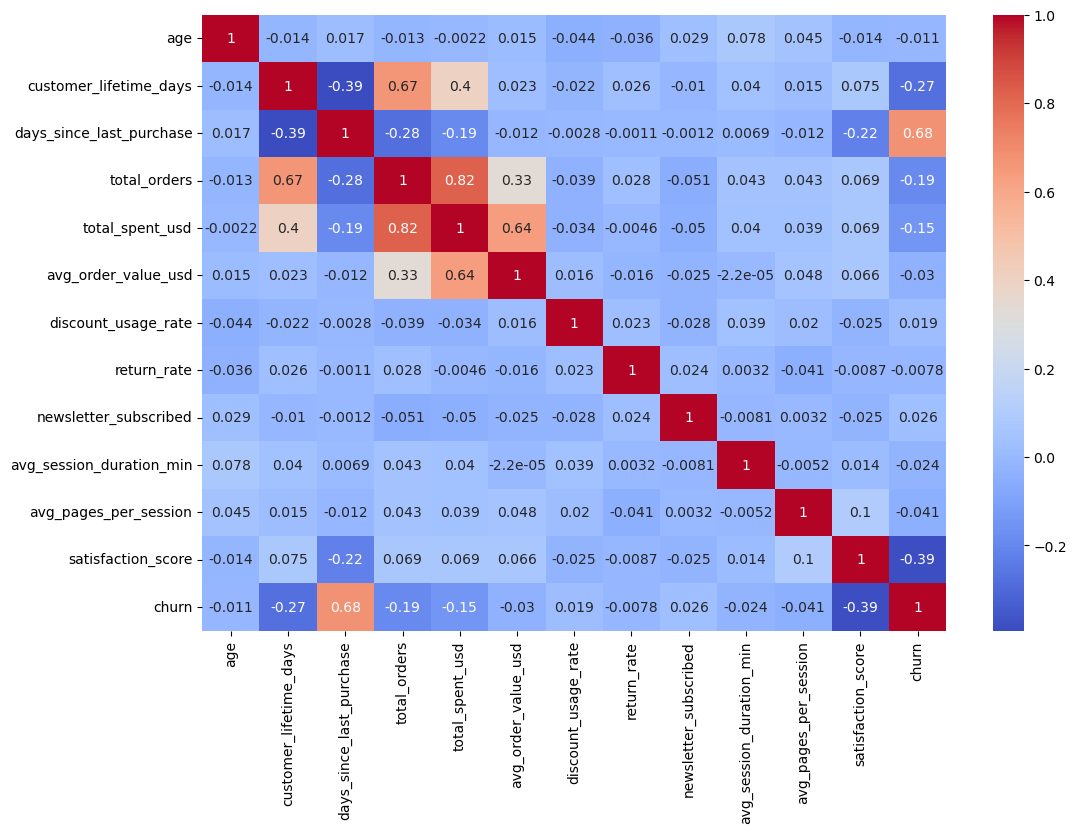

<Figure size 640x480 with 0 Axes>

In [25]:
# HEAT MAP
plt.figure(figsize=(12,8))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)
plt.show()
plt.savefig(r"D:\Analytics\All Projects\Global E-commerce Customer Analytics\Correlation")

**Phase 5: Customer Segmentation(RFM) Analysis**

*Check Distributions*

In [26]:
df[['days_since_last_purchase',
    'total_orders',
    'total_spent_usd']].describe()

,days_since_last_purchase,total_orders,total_spent_usd
count,1200.000000,1200.000000,1200.000000
mean,638.739167,54.095000,5300.141033
std,485.209951,58.386415,9462.359979
min,0.000000,1.000000,7.290000
25%,249.000000,14.000000,795.420000
50%,521.500000,35.000000,2195.495000
75%,925.500000,72.250000,5827.155000
max,2152.000000,350.000000,107142.560000


*CREATE R SCORE*

In [27]:
#LOWER DAYS = BETTER CUSTOMERS
df['R_score'] = pd.qcut(
    df['days_since_last_purchase'],
    q=5,
    labels=[5,4,3,2,1]
)

*CREATE F SCORE*

In [28]:
#HIGHER ORDERS=BETTER
df['F_score'] = pd.qcut(
    df['total_orders'],
    q=5,
    labels=[1,2,3,4,5]
)

*CREATE M SCORE*

In [30]:
#HIGH SPENDING = BETTER
df['M_score'] = pd.qcut(
    df['total_spent_usd'],
    q=5,
    labels=[1,2,3,4,5]
)

*CREATE RFM SCORE*

In [31]:
df['R_score'] = df['R_score'].astype(int)
df['F_score'] = df['F_score'].astype(int)
df['M_score'] = df['M_score'].astype(int)
df['RFM_Score'] = (
    df['R_score'] +
    df['F_score'] +
    df['M_score']
)

*CREATE SEGMENTS*

In [32]:
def segment_customer(score):

    if score >= 13:
        return 'Champions'

    elif score >= 10:
        return 'Loyal Customers'

    elif score >= 7:
        return 'Potential Loyalists'

    elif score >= 4:
        return 'At Risk'

    else:
        return 'Lost Customers'

df['Customer_Segment'] = df['RFM_Score'].apply(segment_customer)

*SEGMENT SUMMARY*

In [33]:
segment_summary = df.groupby(
    'Customer_Segment'
).agg(
    Customers=('customer_id','count'),
    Revenue=('total_spent_usd','sum'),
    Avg_Spend=('total_spent_usd','mean'),
    Avg_Orders=('total_orders','mean')
)

segment_summary

,Customers,Revenue,Avg_Spend,Avg_Orders
Customer_Segment,,,,
At Risk,269,199355.79,741.099591,11.330855
Champions,235,3707839.85,15778.041915,131.370213
Lost Customers,74,15786.27,213.327973,3.851351
Loyal Customers,320,1848850.02,5777.656313,67.303125
Potential Loyalists,302,588337.31,1948.136788,30.370861


*REVENUE CONTRIBUTION*

In [35]:
segment_summary['Revenue_%'] = (
    segment_summary['Revenue']
    /
    segment_summary['Revenue'].sum()
)*100
segment_summary

,Customers,Revenue,Avg_Spend,Avg_Orders,Revenue_%
Customer_Segment,,,,,
At Risk,269,199355.79,741.099591,11.330855,3.134442
Champions,235,3707839.85,15778.041915,131.370213,58.297817
Lost Customers,74,15786.27,213.327973,3.851351,0.248205
Loyal Customers,320,1848850.02,5777.656313,67.303125,29.069195
Potential Loyalists,302,588337.31,1948.136788,30.370861,9.250340


In [36]:
res=df.groupby('Customer_Segment').agg({
    'churn':'mean',
    'days_since_last_purchase':'mean',
    'satisfaction_score':'mean'
})
res

,churn,days_since_last_purchase,satisfaction_score
Customer_Segment,,,
At Risk,0.944238,928.468401,3.096654
Champions,0.306383,235.255319,3.765957
Lost Customers,1.000000,1517.513514,3.027027
Loyal Customers,0.587500,489.884375,3.465625
Potential Loyalists,0.728477,637.036424,3.321192


In [37]:
df.columns

Index(['customer_id', 'age', 'gender', 'country', 'region', 'income_bracket',
       'signup_date', 'last_purchase_date', 'customer_lifetime_days',
       'days_since_last_purchase', 'total_orders', 'total_spent_usd',
       'avg_order_value_usd', 'preferred_category', 'preferred_payment_method',
       'device_type', 'loyalty_tier', 'discount_usage_rate', 'return_rate',
       'newsletter_subscribed', 'referral_source', 'avg_session_duration_min',
       'avg_pages_per_session', 'satisfaction_score', 'churn', 'R_score',
       'F_score', 'M_score', 'RFM_Score', 'Customer_Segment'],
      dtype='object')

In [38]:
df.to_csv(
    r'D:\Analytics\All Projects\Global E-commerce Customer Analytics\ecommerce_customer_analytics_final.csv',
    index=False
)